In [1]:
# Install libraries (run once)
!pip install pandas scikit-learn

# Import
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [2]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [3]:
import zipfile

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("/content/nslkdd")

print("Extracted successfully ✅")

Extracted successfully ✅


In [4]:
import os

os.listdir("/content/nslkdd")

['KDDTrain+.txt',
 'KDDTrain1.jpg',
 'KDDTest+.arff',
 'KDDTest1.jpg',
 'KDDTrain+_20Percent.txt',
 'KDDTest+.txt',
 'nsl-kdd',
 'KDDTrain+_20Percent.arff',
 'index.html',
 'KDDTrain+.arff',
 'KDDTest-21.arff',
 'KDDTest-21.txt']

In [5]:
import pandas as pd

train_path = "/content/nslkdd/KDDTrain+.txt"
test_path = "/content/nslkdd/KDDTest+.txt"

df_train = pd.read_csv(train_path, header=None)
df_test = pd.read_csv(test_path, header=None)

df_train.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [6]:
COL_NAMES = [f"feature_{i}" for i in range(df_train.shape[1])]

df_train.columns = COL_NAMES
df_test.columns = COL_NAMES

df_train.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [7]:
# ===============================
# STEP 1: Select Data
# ===============================
X_train = df_train.iloc[:, :-2]
X_test = df_test.iloc[:, :-2]

# 👉 Select only first 5 features
X_train = X_train.iloc[:, :5]
X_test = X_test.iloc[:, :5]

# ✅ Assign correct column names
X_train.columns = ["duration", "protocol_type", "service", "flag", "src_bytes"]
X_test.columns = X_train.columns

# ===============================
# STEP 2: Encoding
# ===============================
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

encoders = {}

for col in ["protocol_type", "service", "flag"]:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    encoders[col] = le

# ===============================
# STEP 3: Scaling
# ===============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===============================
# STEP 4: Model
# ===============================
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.1, random_state=42)
model.fit(X_train)

# ===============================
# STEP 5: Save
# ===============================
joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoders, "encoders.pkl")

print("✅ Everything saved successfully")

✅ Everything saved successfully


In [9]:
y_test = df_test.iloc[:, -2]   # reload original labels

# Convert to binary
y_test = y_test.apply(lambda x: 0 if x == "normal" else 1)

print(y_test.unique())

[1 0]


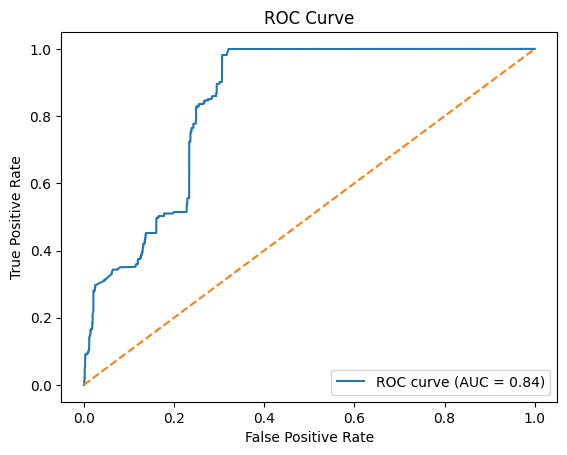

In [10]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# scores
scores = model.decision_function(X_test)

# ROC
fpr, tpr, thresholds = roc_curve(y_test, -scores)
roc_auc = roc_auc_score(y_test, -scores)

plt.plot(fpr, tpr, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

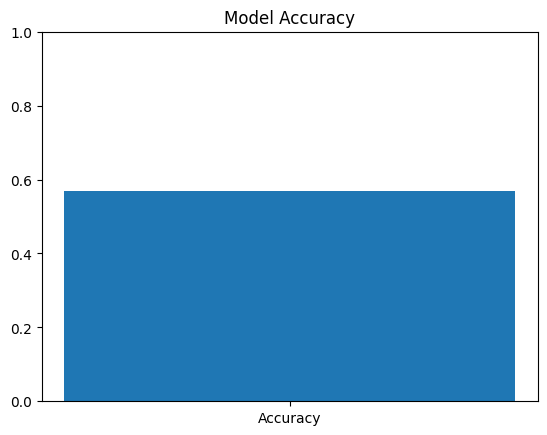

In [11]:
import matplotlib.pyplot as plt

accuracy = (y_test).sum() / len(y_test)

plt.bar(["Accuracy"], [accuracy])
plt.ylim(0,1)
plt.title("Model Accuracy")
plt.show()

In [12]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 80.8 MB/s eta 0:00:00


In [13]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [14]:
%%writefile app.py

import streamlit as st
import numpy as np
import pandas as pd
import joblib

# Load
model = joblib.load("model.pkl")
scaler = joblib.load("scaler.pkl")
encoders = joblib.load("encoders.pkl")

st.set_page_config(page_title="Anomaly Detection", layout="centered")

st.title("🚀 Network Anomaly Detection")
st.write("Enter network traffic details:")

# Inputs
duration = st.number_input("Duration", min_value=0.0)

protocol = st.selectbox("Protocol", encoders["protocol_type"].classes_)
service = st.selectbox("Service", encoders["service"].classes_)
flag = st.selectbox("Flag", encoders["flag"].classes_)

src_bytes = st.number_input("Source Bytes", min_value=0.0)

# Predict
if st.button("Predict"):

    try:
        # Encode
        protocol_enc = encoders["protocol_type"].transform([protocol])[0]
        service_enc = encoders["service"].transform([service])[0]
        flag_enc = encoders["flag"].transform([flag])[0]

        # Create DataFrame
        data = pd.DataFrame([[
            duration,
            protocol_enc,
            service_enc,
            flag_enc,
            src_bytes
        ]], columns=["duration", "protocol_type", "service", "flag", "src_bytes"])

        # Scale
        data_scaled = scaler.transform(data)

        # Predict
        pred = model.predict(data_scaled)

        st.subheader("Result:")

        if pred[0] == -1:
            st.error("🚨 Anomaly Detected (Attack Traffic)")
        else:
            st.success("✅ Normal Traffic")

    except Exception as e:
        st.error(f"Error: {e}")

Writing app.py


In [15]:
!pip install pyngrok

In [16]:
from pyngrok import ngrok
import time

# Your auth token
ngrok.set_auth_token("3CD8PR96hoyxpKmv0LB3lEcELDF_4ZgBhEnTeEbZRbTmVCzzA")

# Kill any existing tunnels
!pkill ngrok

# Start Streamlit
get_ipython().system_raw('streamlit run app.py &')

# Wait for app to start
time.sleep(10)

# Connect ngrok
public_url = ngrok.connect(addr=8501, bind_tls=True)
print("Your App URL:", public_url)

Your App URL: NgrokTunnel: "https://awry-lapped-down.ngrok-free.dev" -> "http://localhost:8501"
